In [1]:
directory='/nfs/cfs/home3/zcfa/zcfairt/GEOG0187/'
filename="MY1_NO2_2024.csv"
file_path=directory+filename
file_path

'/nfs/cfs/home3/zcfa/zcfairt/GEOG0187/MY1_NO2_2024.csv'

In [2]:
import os.path
os.path.isfile(file_path)

True

In [3]:
# Import relevant packages
import csv
import numpy as np

# Open the file:
with open(file_path, newline='', encoding='utf-8') as f:
    # Read the file:
    reader = csv.reader(f, delimiter=',')
    # Declare variables to extract from file:
    row_names = []
    col_names = []
    MY1_NO2_2024 = []
    # Loop over rows in file:
    for row in reader:
        # Identify row with column names:
        if row[0]=="   Date   ":
            col_names=row
        # Identify rows with row name and data values:
        if row[0][6:]=="2024" or row[0][8:]=="2024":
            # Loop over data items in row:
            for i, rr in enumerate(row[1:]):
                # Find blank cells and change to not-a-number (np.nan):
                if rr=="      ":
                    rr = np.nan
                # Append data to 1D array:
                MY1_NO2_2024.append(np.array(rr))
            # Append first entry to row names:
            row_names.append(row[0])


In [4]:
len(MY1_NO2_2024)

8784

In [5]:
type(MY1_NO2_2024)

list

In [6]:
MY1_NO2_2024 = np.array(MY1_NO2_2024)
MY1_NO2_2024 = MY1_NO2_2024.astype(float)

In [7]:
np.nanmin(MY1_NO2_2024)

np.float64(0.0)

In [8]:
np.nanmax(MY1_NO2_2024)

np.float64(128.32875)

In [9]:
np.count_nonzero(np.isnan(MY1_NO2_2024))

430

In [10]:
print(np.nanmean(MY1_NO2_2024))

36.05105997127125


In [11]:
print(np.nanstd(MY1_NO2_2024))

18.88700844735503


In [12]:
np.nanmedian(MY1_NO2_2024)

np.float64(34.0425)

In [13]:
np.nanpercentile(MY1_NO2_2024,[25,75])

array([21.42 , 48.195])

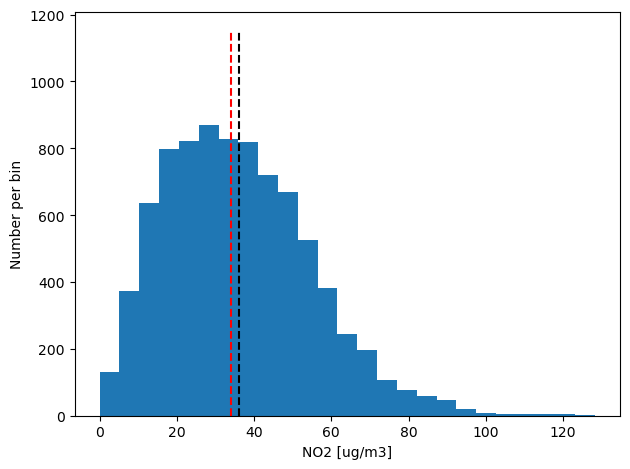

In [14]:
# Import packages needed to plot histogram:
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
# Define plot window:
fig, axs = plt.subplots(1, 1, sharey=True, tight_layout=True)
# Declare number of bins:
n_bins = 25
# Plot the histogram:
axs.hist(MY1_NO2_2024, bins=n_bins)
# Add axes labels:
axs.set_ylabel('Number per bin')
axs.set_xlabel('NO2 [ug/m3]')
# Identify location of mean:
axs.vlines(x=np.nanmean(MY1_NO2_2024), ymin=0, ymax=1150, colors='k', linestyles='--')
# Identify location of median:
axs.vlines(x=np.nanmedian(MY1_NO2_2024), ymin=0, ymax=1150, colors='r', linestyles='--')
